Upload the dataset and extract

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [3]:
import zipfile

zip_file = "archive (3).zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("resume_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


Load all 220 resumes

In [4]:
import os
import glob
import json
import pandas as pd

json_files = glob.glob(
    "resume_dataset/**/*.json",
    recursive=True
)

data = []

for file_path in json_files:
    with open(file_path, "r", encoding="utf-8") as file:
        resume = json.load(file)

    data.append({
        "id": resume["id"],
        "text": resume["text"],
        "skills": resume["skills"]
    })

df = pd.DataFrame(data)

print("Number of resumes:", len(df))
print("Columns:", list(df.columns))

Number of resumes: 220
Columns: ['id', 'text', 'skills']


In [5]:
df.head()

,id,text,skills
0,219,Valarmathi Dhandapani\nInvestment Banking Oper...,"[Martini (Trading System), IT Support Liaison,..."
1,137,"Krishna Prasad\nPatna City, Bihar - Email me o...",[Data Entry]
2,71,Sai Patha\nMule ESB Integration Developer - Ci...,"[Health sheet generation, Production proactive..."
3,99,Vijayalakshmi Govindarajan\nSAP as a Consultan...,"[Problem-solving skills, Solution Manager (SAP..."
4,117,"Divesh Singh\nBengaluru, Karnataka - Email me ...","[Positive Attitude, Hard & Smart Working, Abil..."


Text Preprocessing

In [6]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(preprocess_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Valarmathi Dhandapani\nInvestment Banking Oper...,valarmathi dhandapani investment banking opera...
1,"Krishna Prasad\nPatna City, Bihar - Email me o...",krishna prasad patna city bihar email me on in...
2,Sai Patha\nMule ESB Integration Developer - Ci...,sai patha mule esb integration developer cisco...
3,Vijayalakshmi Govindarajan\nSAP as a Consultan...,vijayalakshmi govindarajan sap as a consultant...
4,"Divesh Singh\nBengaluru, Karnataka - Email me ...",divesh singh bengaluru karnataka email me on i...


Create our Skill Vocabulary

In [7]:
# Create a unique list of all skills in the dataset

all_skills = []

for skills in df["skills"]:
    all_skills.extend(skills)

skill_vocabulary = sorted(set(all_skills))

print("Total unique skills:", len(skill_vocabulary))
print("\nFirst 20 skills:")
print(skill_vocabulary[:20])

Total unique skills: 8757

First 20 skills:
["'Go Live' activities", '.NET', '.NET API', '.NET Framework', '.NET Framework 3.5', '.NET Framework 4.0', '.NET Framework 4.5', '.NET Framework 4.7', '.NET Migration', '.NET Platform', '.NET Remoting', '.Net', '.Net 4.5', '.Net App Development', '.Net Testing', '.Net technology', '.UNV to .UNX Conversion', '.net', '1st Level Troubleshooting', '24*7 Production support']


In [8]:
import re

def extract_skills(text, skill_vocabulary):
    text = text.lower()
    extracted = []

    for skill in skill_vocabulary:
        skill_lower = skill.lower().strip()

        pattern = r'\b' + re.escape(skill_lower) + r'\b'

        if re.search(pattern, text):
            extracted.append(skill)

    return extracted

In [9]:
test_resume = df.iloc[0]

extracted_skills = extract_skills(
    test_resume["text"],
    skill_vocabulary
)

print("Resume ID:", test_resume["id"])
print("\nExtracted Skills:")
print(extracted_skills)
print("\nNumber of Skills Extracted:", len(extracted_skills))

Resume ID: 219

Extracted Skills:
['ACCESS', 'AUDITING', 'Accountability', 'Accounts', 'Analytics', 'Attention to Detail', 'Auditing', 'Banking', 'Banking Operations', 'Billing', 'Bio Informatics', 'Bloomberg', 'Budgeting', 'Buffer Utilization', 'CRL Applications', 'Capital Markets', 'Charts', 'Client meetings', 'Cloud', 'Communication', 'Communication Skills', 'Communication skills', 'Compilation', 'Compliance', 'Confident', 'Coordinating', 'Cost Estimation', 'DATABASE', 'Data Management', 'Data management', 'Database', 'Deployment', 'Development', 'EXCEL', 'Estimation', 'Excel', 'FINANCIAL ANALYST', 'FIRC-Analytics', 'Finance', 'Fixed Income', 'Fixed Income Reconciliation', 'Futures & Options', 'HTTPS', 'IT', 'IT Support', 'ITES', 'Initiative', 'Instrument Data Strategy', 'Internet', 'Internet Applications', 'Intersystem Controls', 'Investment Banking', 'Invoicing', 'MAINTENANCE', 'MENTORING', 'MS OFFICE', 'MS Office', 'MS office', 'MSA', 'Mainframe', 'Maintaining', 'Maintenance', 'M

In [10]:
actual_skills = set(
    skill.lower().strip()
    for skill in test_resume["skills"]
)

predicted_skills = set(
    skill.lower().strip()
    for skill in extracted_skills
)

correct_skills = actual_skills.intersection(predicted_skills)

print("Actual skills:", len(actual_skills))
print("Predicted skills:", len(predicted_skills))
print("Correctly extracted:", len(correct_skills))

print("\nCorrectly extracted skills:")
print(sorted(correct_skills))

Actual skills: 184
Predicted skills: 102
Correctly extracted: 40

Correctly extracted skills:
['auditing', 'banking', 'bio informatics', 'bloomberg', 'budgeting', 'buffer utilization', 'capital markets', 'cost estimation', 'crl applications', 'excel', 'firc-analytics', 'fixed income reconciliation', 'futures & options', 'ifind', 'initiative', 'instrument data strategy', 'internet applications', 'intersystem controls', 'invoicing', 'ites', 'itime', 'mainframe', 'mentoring', 'monitoring', 'oracle bpm tool', 'partner data management', 'po creation', 'prince 2 practitioner', 'project budgeting', 'project management', 'project management tools', 'project planning', 'project reporting', 'resource allocation', 'resource management', 'resource onboarding', 'revenue recognition', 'service excellence', 'sharepoint', 'telekurs international']


In [11]:
short_skills = [
    skill for skill in skill_vocabulary
    if len(skill.strip()) <= 3
]

print("Skills with 3 or fewer characters:", len(short_skills))
print("\nExamples:")
print(short_skills[:100])

Skills with 3 or fewer characters: 179

Examples:
['AAA', 'AC', 'ACL', 'ADF', 'ALM', 'ANT', 'AP', 'API', 'APS', 'AR', 'ARP', 'ASP', 'AWS', 'Ads', 'Ant', 'BCP', 'BDC', 'BDD', 'BGP', 'BI', 'BSS', 'C', 'C#', 'C++', 'CA7', 'CAD', 'CAM', 'CAP', 'CCW', 'CFA', 'CIS', 'CRM', 'CSM', 'CSS', 'CSV', 'CVS', 'Css', 'D2K', 'DAO', 'DB2', 'DCS', 'DNS', 'DTO', 'EBS', 'EC2', 'ECC', 'EDB', 'EDI', 'EFS', 'EJB', 'ELB', 'EM7', 'ERP', 'ETL', 'EVC', 'FA', 'FTP', 'GCD', 'GDT', 'GIT', 'GL', 'GRE', 'GSD', 'GSM', 'GUI', 'GWT', 'Git', 'HDL', 'HRW', 'I2C', 'IAM', 'IC', 'IE', 'IFW', 'IIS', 'ISL', 'ISO', 'ISU', 'IT', 'JCL', 'JDK', 'JMS', 'JPA', 'JRE', 'JSP', 'Jar', 'KVM', 'LAN', 'LVM', 'MBA', 'MFC', 'MSA', 'MVC', 'Mac', 'MoQ', 'Moq', 'NAT', 'NLP', 'NOC', 'ODI']


In [12]:
# Normalize the skill vocabulary

normalized_skills = {}

for skill in skill_vocabulary:
    key = skill.lower().strip()

    if key not in normalized_skills:
        normalized_skills[key] = skill

print("Original unique skills:", len(skill_vocabulary))
print("Normalized unique skills:", len(normalized_skills))

Original unique skills: 8757
Normalized unique skills: 8258


In [13]:
import re

def improved_extract_skills(text, normalized_skills):
    text = text.lower()
    extracted = []

    for skill_key, original_skill in normalized_skills.items():
        # Special handling for skills containing symbols
        if skill_key in ["c++", "c#", ".net"]:
            pattern = re.escape(skill_key)
        else:
            pattern = r"\b" + re.escape(skill_key) + r"\b"

        if re.search(pattern, text):
            extracted.append(original_skill)

    return extracted

print("Improved skill extractor created successfully!")

Improved skill extractor created successfully!


In [14]:
improved_skills = improved_extract_skills(
    test_resume["text"],
    normalized_skills
)

print("Resume ID:", test_resume["id"])

print("\nImproved Extracted Skills:")
print(improved_skills)

print("\nNumber of Skills Extracted:", len(improved_skills))

Resume ID: 219

Improved Extracted Skills:
['ACCESS', 'AUDITING', 'Accountability', 'Accounts', 'Analytics', 'Attention to Detail', 'Banking', 'Banking Operations', 'Billing', 'Bio Informatics', 'Bloomberg', 'Budgeting', 'Buffer Utilization', 'CRL Applications', 'Capital Markets', 'Charts', 'Client meetings', 'Cloud', 'Communication', 'Communication Skills', 'Compilation', 'Compliance', 'Confident', 'Coordinating', 'Cost Estimation', 'DATABASE', 'Data Management', 'Deployment', 'Development', 'EXCEL', 'Estimation', 'FINANCIAL ANALYST', 'FIRC-Analytics', 'Finance', 'Fixed Income', 'Fixed Income Reconciliation', 'Futures & Options', 'HTTPS', 'IT', 'IT Support', 'ITES', 'Initiative', 'Instrument Data Strategy', 'Internet', 'Internet Applications', 'Intersystem Controls', 'Investment Banking', 'Invoicing', 'MAINTENANCE', 'MENTORING', 'MS OFFICE', 'MSA', 'Mainframe', 'Maintaining', 'Management', 'Manual', 'Metrics', 'Monitoring', 'ORACLE', 'Onboarding', 'Oracle BPM Tool', 'Organized', 'PO',

In [15]:
generic_skills = {
    "r",
    "it",
    "management",
    "support",
    "planning",
    "development",
    "deployment",
    "maintenance",
    "monitoring",
    "reporting",
    "responsible",
    "organized",
    "performing",
    "strategy",
    "internet",
    "software",
    "accounts",
    "payments",
    "presentation",
    "tracking",
    "manual",
    "analytics"
}

filtered_skills = {
    skill: original_skill
    for skill, original_skill in normalized_skills.items()
    if skill not in generic_skills
}

print("Before filtering:", len(normalized_skills))
print("After filtering:", len(filtered_skills))

Before filtering: 8258
After filtering: 8236


In [16]:
def final_extract_skills(text, filtered_skills):
    text = text.lower()
    extracted = []

    for skill_key, original_skill in filtered_skills.items():

        if skill_key in ["c++", "c#", ".net"]:
            pattern = re.escape(skill_key)
        else:
            pattern = r"\b" + re.escape(skill_key) + r"\b"

        if re.search(pattern, text):
            extracted.append(original_skill)

    return extracted

print("Final skill extractor created successfully!")

Final skill extractor created successfully!


In [17]:
final_skills = final_extract_skills(
    test_resume["text"],
    filtered_skills
)

print("Resume ID:", test_resume["id"])

print("\nFinal Extracted Skills:")
print(final_skills)

print("\nNumber of Skills Extracted:", len(final_skills))

Resume ID: 219

Final Extracted Skills:
['ACCESS', 'AUDITING', 'Accountability', 'Attention to Detail', 'Banking', 'Banking Operations', 'Billing', 'Bio Informatics', 'Bloomberg', 'Budgeting', 'Buffer Utilization', 'CRL Applications', 'Capital Markets', 'Charts', 'Client meetings', 'Cloud', 'Communication', 'Communication Skills', 'Compilation', 'Compliance', 'Confident', 'Coordinating', 'Cost Estimation', 'DATABASE', 'Data Management', 'EXCEL', 'Estimation', 'FINANCIAL ANALYST', 'FIRC-Analytics', 'Finance', 'Fixed Income', 'Fixed Income Reconciliation', 'Futures & Options', 'HTTPS', 'IT Support', 'ITES', 'Initiative', 'Instrument Data Strategy', 'Internet Applications', 'Intersystem Controls', 'Investment Banking', 'Invoicing', 'MENTORING', 'MS OFFICE', 'MSA', 'Mainframe', 'Maintaining', 'Metrics', 'ORACLE', 'Onboarding', 'Oracle BPM Tool', 'PO', 'PO Creation', 'POWERPOINT', 'PROJECT MANAGEMENT', 'Partner Data Management', 'Prince 2 Practitioner', 'Process Improvements', 'Procurement'

In [18]:
actual_skills = set(
    skill.lower().strip()
    for skill in test_resume["skills"]
)

predicted_skills = set(
    skill.lower().strip()
    for skill in final_skills
)

correct_skills = actual_skills.intersection(predicted_skills)

true_positive = len(correct_skills)
false_positive = len(predicted_skills - actual_skills)
false_negative = len(actual_skills - predicted_skills)

precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)

if precision + recall > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0

print("True Positives:", true_positive)
print("False Positives:", false_positive)
print("False Negatives:", false_negative)

print("\nPrecision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1_score, 4))

True Positives: 39
False Positives: 41
False Negatives: 145

Precision: 0.4875
Recall: 0.212
F1-score: 0.2955


In [19]:
false_negatives = sorted(actual_skills - predicted_skills)

print("Number of missed skills:", len(false_negatives))
print("\nFirst 50 missed skills:")
print(false_negatives[:50])

Number of missed skills: 145

First 50 missed skills:
['account opening (institutional, wholesale, fits)', 'accrued interest calculation', 'adaptability', 'adhoc reporting', 'admin q management', 'alcon (allocation and confirmation)', 'allocations management', 'analytical skills', 'application access management', 'application development support', 'application error analysis', 'application support', 'australian fixed income trading systems', 'background verification (bgv)', 'be report tracking', 'brokerage operations', 'brokerage rate remediation', 'bulk data update', 'cash reconciliation', 'cdr (central data repository)', 'chart creation', 'check creation', 'client communication', 'client conference calls', 'client data reporting', 'client management', 'client onboarding', 'client visit coordination', 'colt (continuous online trading) system', 'complexity reduction', 'compliance management', 'confidence', 'dashboard creation', 'data analytics', 'data issue resolution', 'data managemen

In [20]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [21]:
total_tp = 0
total_fp = 0
total_fn = 0

for _, row in df.iterrows():

    predicted = set(
        skill.lower().strip()
        for skill in final_extract_skills(
            row["text"],
            filtered_skills
        )
    )

    actual = set(
        skill.lower().strip()
        for skill in row["skills"]
    )

    total_tp += len(predicted & actual)
    total_fp += len(predicted - actual)
    total_fn += len(actual - predicted)

precision = total_tp / (total_tp + total_fp)
recall = total_tp / (total_tp + total_fn)
f1 = 2 * precision * recall / (precision + recall)

print("Total True Positives:", total_tp)
print("Total False Positives:", total_fp)
print("Total False Negatives:", total_fn)

print("\nOverall Precision:", round(precision, 4))
print("Overall Recall:", round(recall, 4))
print("Overall F1-score:", round(f1, 4))

Total True Positives: 6737
Total False Positives: 6030
Total False Negatives: 6075

Overall Precision: 0.5277
Overall Recall: 0.5258
Overall F1-score: 0.5268


In [22]:
df["extracted_skills"] = df["text"].apply(
    lambda text: final_extract_skills(
        text,
        filtered_skills
    )
)

print("Skill extraction completed for all resumes!")
print(df[["id", "extracted_skills"]].head())

Skill extraction completed for all resumes!
    id                                   extracted_skills
0  219  [ACCESS, AUDITING, Accountability, Attention t...
1  137           [Data Entry, HTTPS, Microsoft, computer]
2   71  [ACCESS, AGILE Methodology, ALGORITHMS, ANT, A...
3   99  [ABAP, ACCESS, Administration, BI, BW ABAP, Ba...
4  117  [Ability to work under tough situation, Abilit...


In [23]:
resume_id = 219

result = df[df["id"] == resume_id].iloc[0]

print("Resume ID:", result["id"])
print("Number of extracted skills:", len(result["extracted_skills"]))

print("\nExtracted Skills:")
for skill in result["extracted_skills"]:
    print("-", skill)

Resume ID: 219
Number of extracted skills: 80

Extracted Skills:
- ACCESS
- AUDITING
- Accountability
- Attention to Detail
- Banking
- Banking Operations
- Billing
- Bio Informatics
- Bloomberg
- Budgeting
- Buffer Utilization
- CRL Applications
- Capital Markets
- Charts
- Client meetings
- Cloud
- Communication
- Communication Skills
- Compilation
- Compliance
- Confident
- Coordinating
- Cost Estimation
- DATABASE
- Data Management
- EXCEL
- Estimation
- FINANCIAL ANALYST
- FIRC-Analytics
- Finance
- Fixed Income
- Fixed Income Reconciliation
- Futures & Options
- HTTPS
- IT Support
- ITES
- Initiative
- Instrument Data Strategy
- Internet Applications
- Intersystem Controls
- Investment Banking
- Invoicing
- MENTORING
- MS OFFICE
- MSA
- Mainframe
- Maintaining
- Metrics
- ORACLE
- Onboarding
- Oracle BPM Tool
- PO
- PO Creation
- POWERPOINT
- PROJECT MANAGEMENT
- Partner Data Management
- Prince 2 Practitioner
- Process Improvements
- Procurement
- Project Budgeting
- Project Del

Make a simple resume input system

In [24]:
resume_id = int(input("Enter Resume ID: "))

result = df[df["id"] == resume_id]

if len(result) == 0:
    print("Resume ID not found.")
else:
    result = result.iloc[0]

    print("\nResume ID:", result["id"])
    print("Number of extracted skills:", len(result["extracted_skills"]))

    print("\nExtracted Skills:")
    for skill in result["extracted_skills"]:
        print("-", skill)

Enter Resume ID: 137

Resume ID: 137
Number of extracted skills: 4

Extracted Skills:
- Data Entry
- HTTPS
- Microsoft
- computer


In [25]:
resume_id = 137

result = df[df["id"] == resume_id].iloc[0]

actual = set(skill.lower().strip() for skill in result["skills"])
predicted = set(skill.lower().strip() for skill in result["extracted_skills"])

print("Resume ID:", resume_id)
print("Actual skills:", len(actual))
print("Extracted skills:", len(predicted))

print("\n--- ACTUAL SKILLS ---")
for skill in sorted(actual):
    print("-", skill)

print("\n--- EXTRACTED SKILLS ---")
for skill in sorted(predicted):
    print("-", skill)

print("\n--- MISSED SKILLS ---")
for skill in sorted(actual - predicted):
    print("-", skill)

Resume ID: 137
Actual skills: 1
Extracted skills: 4

--- ACTUAL SKILLS ---
- data entry

--- EXTRACTED SKILLS ---
- computer
- data entry
- https
- microsoft

--- MISSED SKILLS ---


In [26]:
df["actual_skill_count"] = df["skills"].apply(len)
df["extracted_skill_count"] = df["extracted_skills"].apply(len)

results_df = df[
    ["id", "actual_skill_count", "extracted_skill_count"]
]

results_df.head(10)

,id,actual_skill_count,extracted_skill_count
0,219,184,80
1,137,1,4
2,71,246,271
3,99,121,81
4,117,9,20
5,149,20,20
6,143,73,52
7,19,34,43
8,54,19,24
9,70,37,47


In [27]:
print("Average actual skills:",
      round(df["actual_skill_count"].mean(), 2))

print("Average extracted skills:",
      round(df["extracted_skill_count"].mean(), 2))

print("Maximum actual skills:",
      df["actual_skill_count"].max())

print("Maximum extracted skills:",
      df["extracted_skill_count"].max())

Average actual skills: 58.25
Average extracted skills: 58.03
Maximum actual skills: 284
Maximum extracted skills: 271


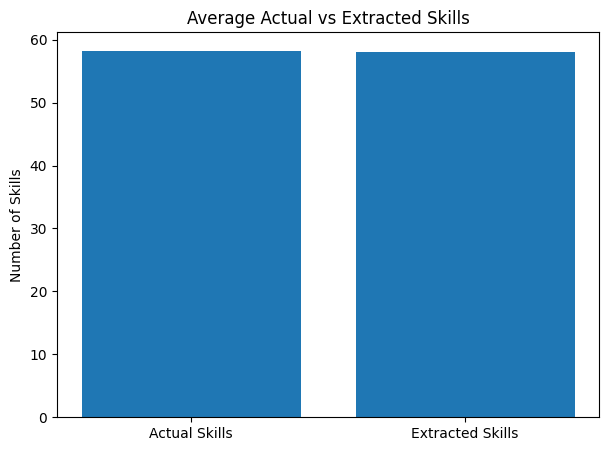

In [28]:
import matplotlib.pyplot as plt

labels = ["Actual Skills", "Extracted Skills"]
values = [
    df["actual_skill_count"].mean(),
    df["extracted_skill_count"].mean()
]

plt.figure(figsize=(7, 5))
plt.bar(labels, values)

plt.title("Average Actual vs Extracted Skills")
plt.ylabel("Number of Skills")
plt.show()

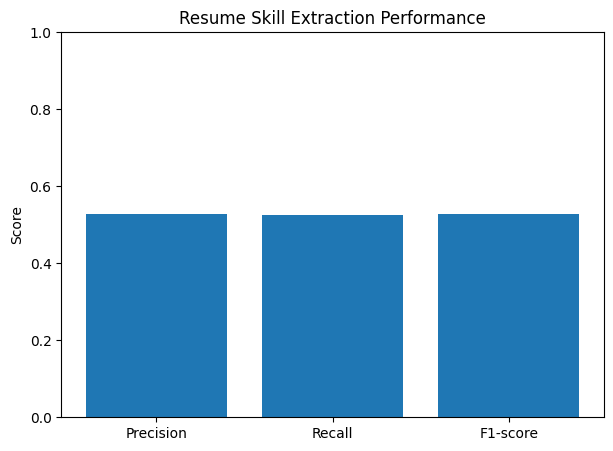

In [29]:
metrics = ["Precision", "Recall", "F1-score"]
values = [precision, recall, f1]

plt.figure(figsize=(7, 5))
plt.bar(metrics, values)

plt.title("Resume Skill Extraction Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

In [30]:
resume_id = int(input("Enter Resume ID: "))

result = df[df["id"] == resume_id]

if len(result) == 0:
    print("Resume ID not found.")

else:
    result = result.iloc[0]

    print("\n===================================")
    print("       RESUME SKILL EXTRACTOR")
    print("===================================")

    print("\nResume ID:", result["id"])
    print("Skills Found:", len(result["extracted_skills"]))

    print("\nExtracted Skills:")
    print("-----------------------------------")

    for i, skill in enumerate(result["extracted_skills"], 1):
        print(f"{i}. {skill}")

Enter Resume ID: 219

       RESUME SKILL EXTRACTOR

Resume ID: 219
Skills Found: 80

Extracted Skills:
-----------------------------------
1. ACCESS
2. AUDITING
3. Accountability
4. Attention to Detail
5. Banking
6. Banking Operations
7. Billing
8. Bio Informatics
9. Bloomberg
10. Budgeting
11. Buffer Utilization
12. CRL Applications
13. Capital Markets
14. Charts
15. Client meetings
16. Cloud
17. Communication
18. Communication Skills
19. Compilation
20. Compliance
21. Confident
22. Coordinating
23. Cost Estimation
24. DATABASE
25. Data Management
26. EXCEL
27. Estimation
28. FINANCIAL ANALYST
29. FIRC-Analytics
30. Finance
31. Fixed Income
32. Fixed Income Reconciliation
33. Futures & Options
34. HTTPS
35. IT Support
36. ITES
37. Initiative
38. Instrument Data Strategy
39. Internet Applications
40. Intersystem Controls
41. Investment Banking
42. Invoicing
43. MENTORING
44. MS OFFICE
45. MSA
46. Mainframe
47. Maintaining
48. Metrics
49. ORACLE
50. Onboarding
51. Oracle BPM Tool
52. P

In [31]:
output_df = df[[
    "id",
    "text",
    "skills",
    "extracted_skills"
]].copy()

output_df.to_csv(
    "resume_skill_extraction_results.csv",
    index=False
)

print("Results saved successfully!")
print("File: resume_skill_extraction_results.csv")

Results saved successfully!
File: resume_skill_extraction_results.csv


In [32]:
print("===== RESUME SKILL EXTRACTION PROJECT =====")

print("\nDataset:")
print("Number of resumes:", len(df))

print("\nSkill Statistics:")
print("Average actual skills:", round(df["actual_skill_count"].mean(), 2))
print("Average extracted skills:", round(df["extracted_skill_count"].mean(), 2))

print("\nEvaluation:")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

===== RESUME SKILL EXTRACTION PROJECT =====

Dataset:
Number of resumes: 220

Skill Statistics:
Average actual skills: 58.25
Average extracted skills: 58.03

Evaluation:
Precision: 0.5277
Recall: 0.5258
F1-score: 0.5268


In [33]:
import os

print(os.path.exists("resume_skill_extraction_results.csv"))

True


In [34]:
from google.colab import files

files.download("resume_skill_extraction_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>